## 1. Importações

In [19]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
import time
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# 1. Carregamento
df_model = pd.read_csv('../data/processed/data_model/dados_model.csv', sep=';')

# 2. Engenharia de Atributos (Turno)
df_model['hora_pura'] = pd.to_datetime(df_model['horario'], format='%H:%M:%S', errors='coerce').dt.hour
if df_model['hora_pura'].isnull().all():
    df_model['hora_pura'] = pd.to_datetime(df_model['horario'], format='%H:%M', errors='coerce').dt.hour

def categorizar_turno(hora):
    if 0 <= hora < 6: return 'Madrugada'
    elif 6 <= hora < 12: return 'Manhã'
    elif 12 <= hora < 18: return 'Tarde'
    else: return 'Noite'

df_model['turno'] = df_model['hora_pura'].apply(categorizar_turno)

# 3. Seleção e One-Hot Encoding
variaveis_explicitas = [
    'turno', 'condicao_metereologica', 'tracado_via', 'fase_dia', 
    'br', 'icm', 'icc', 'icp', 'tipo_pista', 'sentido_via', 
    'tipo_veiculo', 'sexo', 'dia_semana', 'uso_solo'
]

X_bruto = df_model[variaveis_explicitas]
y = df_model['acidente_grave_ou_fatal']

colunas_categoricas = [
    'turno', 'condicao_metereologica', 'tracado_via', 'fase_dia', 
    'br', 'tipo_pista', 'sentido_via', 'tipo_veiculo', 'sexo', 'dia_semana', 'uso_solo'
]

X_final = pd.get_dummies(X_bruto, columns=colunas_categoricas, drop_first=True)
for col in X_final.columns:
    if X_final[col].dtype == 'bool':
        X_final[col] = X_final[col].astype(int)

# 4. Divisão e Padronização
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.3, random_state=42, stratify=y
)

colunas_numericas = ['icm', 'icc', 'icp']
scaler = StandardScaler()
X_train[colunas_numericas] = scaler.fit_transform(X_train[colunas_numericas])
X_test[colunas_numericas] = scaler.transform(X_test[colunas_numericas])

print("✅ Setup Concluído! O ambiente está limpo e os dados estão prontos para a arena de modelos.")

✅ Setup Concluído! O ambiente está limpo e os dados estão prontos para a arena de modelos.


## 2. CONFIGURAÇÃO DOS MODELOS AVANÇADOS

In [20]:
# 1. Carregando o modelo Baseline que foi treinado e salvo no Notebook 3
# Ele já vem com todos os pesos calculados e o class_weight ajustado lá atrás!
modelo_baseline_carregado = joblib.load('../models/modelo_baseline.pkl')

# 2. Cálculo do peso dinâmico para o XGBoost equilibrar as classes
peso_balanceamento_xgb = y_train.value_counts()[0] / y_train.value_counts()[1]

# Limpeza de segurança nos nomes das colunas para o XGBoost/LightGBM
X_train.columns = X_train.columns.str.replace(r'[\[\]<>]', '', regex=True)
X_test.columns = X_test.columns.str.replace(r'[\[\]<>]', '', regex=True)

# 3. Dicionário com os competidores
# Repare que os modelos avançados serão treinados agora, mas o Baseline já está pronto
modelos = {
    'Regressão Logística (Baseline Salvo)': modelo_baseline_carregado,
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(scale_pos_weight=peso_balanceamento_xgb, random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
}

print("✅ Modelo Baseline carregado do arquivo e novos modelos instanciados!")

✅ Modelo Baseline carregado do arquivo e novos modelos instanciados!


## 3. TREINAMENTO COMPARATIVO (A ARENA)

In [21]:
from imblearn.over_sampling import SMOTE

print("Distribuição original do Treino:", y_train.value_counts().to_dict())

# Aplicando a clonagem inteligente de acidentes graves para empatar o jogo
smote = SMOTE(random_state=42)
X_train_balanceado, y_train_balanceado = smote.fit_resample(X_train, y_train)

print("Distribuição após o SMOTE:", y_train_balanceado.value_counts().to_dict())

# O seu código de treinamento segue igual, mas usando o X_train_balanceado
# modelo.fit(X_train_balanceado, y_train_balanceado)

Distribuição original do Treino: {0: 127271, 1: 18972}
Distribuição após o SMOTE: {1: 127271, 0: 127271}


In [22]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve
import pandas as pd

print("Iniciando a bateria de testes. Acompanhe o progresso abaixo:\n")

resultados = []
curvas_roc = {}  # Guardará as coordenadas para o gráfico da próxima célula

for nome, modelo in modelos.items():
    print(f"🏋️ Treinando o modelo: {nome}...")
    
    # Cronometrando o tempo de execução
    tempo_inicio = time.time()
    modelo.fit(X_train, y_train)
    tempo_gasto = time.time() - tempo_inicio
    
    # Realizando as previsões no conjunto de teste (inédito)
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    
    # Extraindo as métricas de performance focadas na Classe 1 (Grave/Fatal)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    # Armazenando os dados da Curva ROC para visualização gráfica posterior
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    curvas_roc[nome] = {'fpr': fpr, 'tpr': tpr, 'auc': auc}
    
    # Consolidação dos resultados na tabela
    resultados.append({
        'Algoritmo': nome,
        'Acurácia': round(acc, 4),
        'Precision (Grave)': round(prec, 4),
        'Recall (Grave)': round(rec, 4),
        'AUC Score': round(auc, 4),
        'Tempo (Segundos)': round(tempo_gasto, 3)
    })

# Convertendo para DataFrame e ordenando pelo AUC Score (métrica de distinção global)
df_comparativo = pd.DataFrame(resultados).sort_values(by='AUC Score', ascending=False)

print("\n📊 --- QUADRO COMPARATIVO DE PERFORMANCE ---")
df_comparativo

Iniciando a bateria de testes. Acompanhe o progresso abaixo:

🏋️ Treinando o modelo: Regressão Logística (Baseline Salvo)...
🏋️ Treinando o modelo: Random Forest...
🏋️ Treinando o modelo: XGBoost...
🏋️ Treinando o modelo: LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 18972, number of negative: 127271
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001960 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1121
[LightGBM] [Info] Number of data points in the train set: 146243, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000

📊 --- QUADRO COMPARATIVO DE PERFORMANCE ---


,Algoritmo,Acurácia,Precision (Grave),Recall (Grave),AUC Score,Tempo (Segundos)
3,LightGBM,0.6897,0.2658,0.7902,0.8122,0.882
2,XGBoost,0.7032,0.2716,0.7657,0.8100,3.700
1,Random Forest,0.8718,0.5135,0.2275,0.8083,16.217
0,Regressão Logística (Baseline Salvo),0.7035,0.2679,0.7417,0.7993,14.815


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve
import pandas as pd

print("Iniciando a bateria de testes. Acompanhe o progresso abaixo:\n")

resultados = []
curvas_roc = {}  # Guardará as coordenadas para o gráfico da próxima célula

for nome, modelo in modelos.items():
    print(f"🏋️ Treinando o modelo: {nome}...")
    
    # Cronometrando o tempo de execução
    tempo_inicio = time.time()
    modelo.fit(X_train_balanceado, y_train_balanceado)
    tempo_gasto = time.time() - tempo_inicio
    
    # Realizando as previsões no conjunto de teste (inédito)
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    
    # Extraindo as métricas de performance focadas na Classe 1 (Grave/Fatal)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    # Armazenando os dados da Curva ROC para visualização gráfica posterior
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    curvas_roc[nome] = {'fpr': fpr, 'tpr': tpr, 'auc': auc}
    
    # Consolidação dos resultados na tabela
    resultados.append({
        'Algoritmo': nome,
        'Acurácia': round(acc, 4),
        'Precision (Grave)': round(prec, 4),
        'Recall (Grave)': round(rec, 4),
        'AUC Score': round(auc, 4),
        'Tempo (Segundos)': round(tempo_gasto, 3)
    })

# Convertendo para DataFrame e ordenando pelo AUC Score (métrica de distinção global)
df_comparativo = pd.DataFrame(resultados).sort_values(by='AUC Score', ascending=False)

print("\n📊 --- QUADRO COMPARATIVO DE PERFORMANCE ---")
df_comparativo

Iniciando a bateria de testes. Acompanhe o progresso abaixo:

🏋️ Treinando o modelo: Regressão Logística (Baseline Salvo)...
🏋️ Treinando o modelo: Random Forest...
🏋️ Treinando o modelo: XGBoost...
🏋️ Treinando o modelo: LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 127271, number of negative: 127271
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002207 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1135
[LightGBM] [Info] Number of data points in the train set: 254542, number of used features: 188
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

📊 --- QUADRO COMPARATIVO DE PERFORMANCE ---


,Algoritmo,Acurácia,Precision (Grave),Recall (Grave),AUC Score,Tempo (Segundos)
1,Random Forest,0.8366,0.3817,0.4186,0.7902,35.001
2,XGBoost,0.4881,0.1900,0.9028,0.7568,6.828
3,LightGBM,0.7591,0.2743,0.5210,0.7543,1.483
0,Regressão Logística (Baseline Salvo),0.7443,0.2633,0.5400,0.7442,45.246


## 4. VISUALIZAÇÃO GRÁFICA: BATALHA DE CURVAS ROC

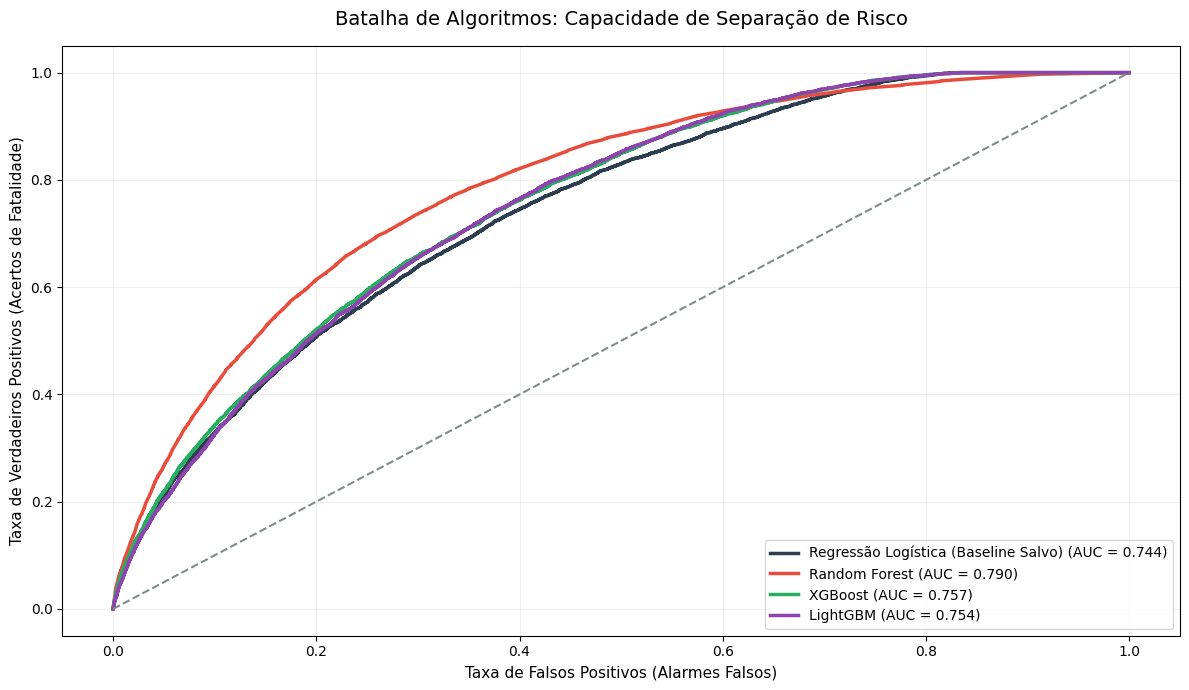

In [24]:


plt.figure(figsize=(12, 7))

# Paleta de cores sóbria e profissional para diferenciar os modelos
cores = ['#2c3e50', '#e74c3c', '#27ae60', '#8e44ad']

# Plotando a curva de cada competidor
for (nome, dados), cor in zip(curvas_roc.items(), cores):
    plt.plot(
        dados['fpr'], 
        dados['tpr'], 
        color=cor, 
        lw=2.5, 
        label=f"{nome} (AUC = {dados['auc']:.3f})"
    )

# Linha de referência nula (Chute Aleatório / Moeda)
plt.plot([0, 1], [0, 1], color='#7f8c8d', lw=1.5, linestyle='--')

plt.title('Batalha de Algoritmos: Capacidade de Separação de Risco', fontsize=14, pad=15)
plt.xlabel('Taxa de Falsos Positivos (Alarmes Falsos)', fontsize=11)
plt.ylabel('Taxa de Verdadeiros Positivos (Acertos de Fatalidade)', fontsize=11)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()